# Expectation-Maximization (EM) Algorithm from Scratch
## Gaussian Mixture Model on the Galton Heights Dataset
### Populations: Fathers (Parents) vs Children

**Team:** Group 11

---

## Objective

We take real height data from two populations — **Fathers** and **Children** — hide the
labels, pool all heights into one anonymous dataset, and implement the EM algorithm
from scratch to model the pool as a mixture of two Gaussian distributions. We track the
optimization step by step, verify the result against the hidden labels, analyze what
structure EM actually discovered, and use the fitted model to classify new heights
with exact posterior probabilities.


## Step 1: Load the Dataset

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GaltonFamilies.csv')
print(f"Rows in file: {len(df)}")
df.head()

Rows in file: 934


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


## Step 2: Build the Two Populations and Remove the Labels

- **Fathers** are deduplicated: the raw file repeats each father once per child
  (934 rows but only 205 unique fathers), so we keep one height per family.
- **Children** are all 934 children (sons and daughters).
- The labels are then removed by concatenating everything into one anonymous array.
  From here on, the algorithm never sees who is who.


In [19]:
# One father height per family (deduplicated)
fathers = df.drop_duplicates(subset='family')['father'].values.astype(float)

# All children (sons and daughters)
children = df['childHeight'].values.astype(float)

# Remove the labels: pool everything into one anonymous dataset
data = np.concatenate([fathers, children])
N = len(data)

print(f"Fathers  : n={len(fathers):4d}  mean={fathers.mean():.4f}  std={fathers.std():.4f}")
print(f"Children : n={len(children):4d}  mean={children.mean():.4f}  std={children.std():.4f}")
print(f"Combined : n={N:4d}  mean={data.mean():.4f}  std={data.std():.4f}")

Fathers  : n= 205  mean=69.3161  std=2.6407
Children : n= 934  mean=66.7459  std=3.5773
Combined : n=1139  mean=67.2085  std=3.5671


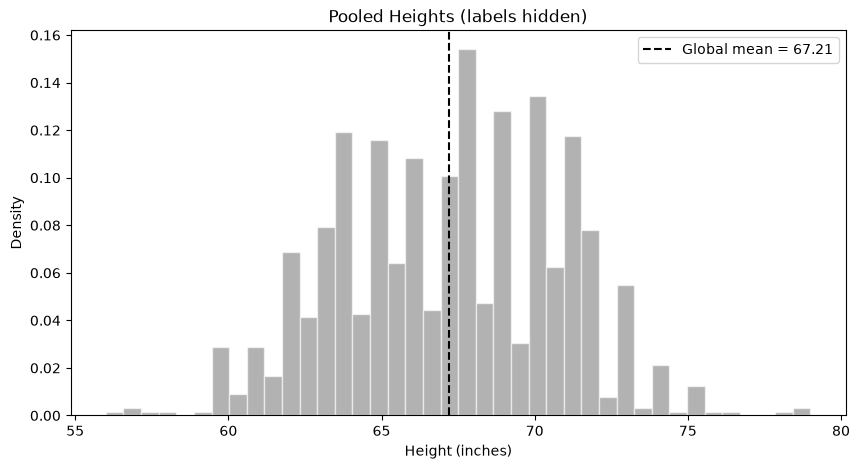

In [20]:
# Visualize the pooled, label-free data
plt.figure(figsize=(10, 5))
plt.hist(data, bins=40, density=True, alpha=0.6, color='gray', edgecolor='white')
plt.axvline(data.mean(), color='black', linestyle='--',
            label=f'Global mean = {data.mean():.2f}')
plt.title('Pooled Heights (labels hidden)')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Step 3: Gaussian Probability Density Function

The building block for everything that follows:

$$\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$


In [21]:
def gaussian_pdf(x, mu, var):
    """Gaussian PDF N(x; mu, var), vectorised over x.
    A variance floor guards against division by zero."""
    var = max(float(var), 1e-10)
    coefficient = 1.0 / np.sqrt(2.0 * np.pi * var)
    exponent = np.exp(-0.5 * (x - mu) ** 2 / var)
    return coefficient * exponent

# Test the function
print(f"N(65.0; mu=65, var=9) = {gaussian_pdf(65.0, 65.0, 9.0):.8f}  (at the mean -> peak)")
print(f"N(78.5; mu=65, var=9) = {gaussian_pdf(78.5, 65.0, 9.0):.8f}  (far away -> tiny)")

N(65.0; mu=65, var=9) = 0.13298076  (at the mean -> peak)
N(78.5; mu=65, var=9) = 0.00000533  (far away -> tiny)


## Step 4: E-Step (Expectation)

For every point, compute the **responsibility** of each cluster — the posterior
probability that the point belongs to it under the current parameters:

$$\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)}{\pi_1 \mathcal{N}(x_i \mid \mu_1, \sigma_1^2) + \pi_2 \mathcal{N}(x_i \mid \mu_2, \sigma_2^2)}$$

These are **soft assignments** — a borderline height contributes partially to both
clusters instead of being forced into one pile.


In [22]:
def e_step(x, pi1, pi2, mu1, mu2, v1, v2):
    """Compute responsibilities gamma_1, gamma_2 for every observation."""
    weighted1 = pi1 * gaussian_pdf(x, mu1, v1)   # pi_1 * N(x; mu_1, var_1)
    weighted2 = pi2 * gaussian_pdf(x, mu2, v2)   # pi_2 * N(x; mu_2, var_2)
    denom = weighted1 + weighted2 + 1e-300        # epsilon guard against 0/0
    return weighted1 / denom, weighted2 / denom

# Test: a short height should belong overwhelmingly to the low-mean cluster
g1, g2 = e_step(np.array([60.0, 72.0]), 0.5, 0.5, 64.0, 69.0, 6.0, 6.0)
print(f"Height 60.0 -> gamma1={g1[0]:.4f}, gamma2={g2[0]:.4f}")
print(f"Height 72.0 -> gamma1={g1[1]:.4f}, gamma2={g2[1]:.4f}")

Height 60.0 -> gamma1=0.9956, gamma2=0.0044
Height 72.0 -> gamma1=0.0101, gamma2=0.9899


## Step 5: M-Step (Maximization)

Re-estimate every parameter using the responsibilities as weights:

$$N_k = \sum_i \gamma_{ik} \qquad
\mu_k = \frac{\sum_i \gamma_{ik} x_i}{N_k} \qquad
\sigma_k^2 = \frac{\sum_i \gamma_{ik}(x_i - \mu_k)^2}{N_k} \qquad
\pi_k = \frac{N_k}{N}$$


In [23]:
def m_step(x, gamma1, gamma2):
    """Update means, variances and mixing coefficients from responsibilities."""
    N = len(x)
    N1, N2 = gamma1.sum(), gamma2.sum()          # effective cluster sizes

    mu1 = (gamma1 * x).sum() / N1                # weighted means
    mu2 = (gamma2 * x).sum() / N2

    v1 = (gamma1 * (x - mu1) ** 2).sum() / N1    # weighted variances
    v2 = (gamma2 * (x - mu2) ** 2).sum() / N2

    pi1, pi2 = N1 / N, N2 / N                    # mixing coefficients
    return mu1, mu2, v1, v2, pi1, pi2

## Step 6: Log-Likelihood

How well the current mixture explains the data. EM guarantees this never decreases:

$$\log L = \sum_i \log\left[\pi_1 \mathcal{N}(x_i \mid \mu_1, \sigma_1^2) + \pi_2 \mathcal{N}(x_i \mid \mu_2, \sigma_2^2)\right]$$


In [24]:
def log_likelihood(x, pi1, pi2, mu1, mu2, v1, v2):
    """Observed-data log-likelihood of the 2-component GMM."""
    mixture = pi1 * gaussian_pdf(x, mu1, v1) + pi2 * gaussian_pdf(x, mu2, v2)
    return float(np.sum(np.log(mixture + 1e-300)))

## Step 7: Initialization Strategies

EM converges to a **local** maximum, so the starting point matters. We prepare two
strategies and later run both:

1. **Manual guesses** from eyeballing the histogram.
2. **K-means seeding** (25th/75th percentile start) — data-driven and more robust.

Initial parameters are passed into the EM function as arguments, never hardcoded inside.


In [25]:
def kmeans_init(x):
    """Tiny 2-cluster k-means producing data-driven initial parameters."""
    c1, c2 = float(np.percentile(x, 25)), float(np.percentile(x, 75))
    for _ in range(200):
        mask = np.abs(x - c1) <= np.abs(x - c2)
        new_c1, new_c2 = x[mask].mean(), x[~mask].mean()
        if abs(new_c1 - c1) + abs(new_c2 - c2) < 1e-10:
            break
        c1, c2 = new_c1, new_c2
    if c1 > c2:
        c1, c2 = c2, c1
        mask = ~mask
    return dict(mu1=c1, mu2=c2, v1=x[mask].var(), v2=x[~mask].var(),
                pi1=mask.mean(), pi2=(~mask).mean())

manual_init = dict(mu1=65.0, mu2=72.0, v1=9.0, v2=9.0, pi1=0.5, pi2=0.5)
km_init = kmeans_init(data)

print("Manual init :", {k: round(float(v), 4) for k, v in manual_init.items()})
print("K-means init:", {k: round(float(v), 4) for k, v in km_init.items()})

Manual init : {'mu1': 65.0, 'mu2': 72.0, 'v1': 9.0, 'v2': 9.0, 'pi1': 0.5, 'pi2': 0.5}
K-means init: {'mu1': 64.2598, 'mu2': 70.2147, 'v1': 4.1428, 'v2': 3.5711, 'pi1': 0.5048, 'pi2': 0.4952}


## Step 8: The Full EM Loop

Repeat E-step → M-step until the log-likelihood improvement falls below tolerance.
Cluster 1 is always kept as the lower-mean group so labels never swap between
iterations.


In [26]:
def expectation_maximization(x, init, max_iter=500, tol=1e-6, verbose=True):
    """Full EM for a 2-component 1-D GMM. Initial parameters are arguments.
    Returns the complete optimization history (including iteration 0)."""
    mu1, mu2 = init['mu1'], init['mu2']
    v1, v2 = init['v1'], init['v2']
    pi1, pi2 = init['pi1'], init['pi2']

    ll = log_likelihood(x, pi1, pi2, mu1, mu2, v1, v2)
    history = [dict(it=0, mu1=mu1, mu2=mu2, v1=v1, v2=v2, pi1=pi1, pi2=pi2, ll=ll)]

    for i in range(1, max_iter + 1):
        gamma1, gamma2 = e_step(x, pi1, pi2, mu1, mu2, v1, v2)      # E-step
        mu1, mu2, v1, v2, pi1, pi2 = m_step(x, gamma1, gamma2)      # M-step

        if mu1 > mu2:   # keep cluster 1 = lower-mean group
            mu1, mu2, v1, v2, pi1, pi2 = mu2, mu1, v2, v1, pi2, pi1

        ll_new = log_likelihood(x, pi1, pi2, mu1, mu2, v1, v2)
        history.append(dict(it=i, mu1=mu1, mu2=mu2, v1=v1, v2=v2,
                            pi1=pi1, pi2=pi2, ll=ll_new))

        if abs(ll_new - ll) < tol:
            if verbose:
                print(f"Converged at iteration {i} (|dLL| < {tol})")
            break
        ll = ll_new
    return history

In [27]:
print("Run A — manual initialization:")
history_manual = expectation_maximization(data, manual_init)

print("\nRun B — k-means initialization:")
history_km = expectation_maximization(data, km_init)

fa, fb = history_manual[-1], history_km[-1]
print("\nConverged solutions:")
print(f"  Manual : mu1={fa['mu1']:.4f}  mu2={fa['mu2']:.4f}  v1={fa['v1']:.4f}  "
      f"v2={fa['v2']:.4f}  pi1={fa['pi1']:.4f}  LL={fa['ll']:.4f}")
print(f"  K-means: mu1={fb['mu1']:.4f}  mu2={fb['mu2']:.4f}  v1={fb['v1']:.4f}  "
      f"v2={fb['v2']:.4f}  pi1={fb['pi1']:.4f}  LL={fb['ll']:.4f}")

# Use the run with the higher final log-likelihood as the final model
history = history_km if fb['ll'] >= fa['ll'] else history_manual

Run A — manual initialization:
Converged at iteration 373 (|dLL| < 1e-06)

Run B — k-means initialization:
Converged at iteration 309 (|dLL| < 1e-06)

Converged solutions:
  Manual : mu1=64.1772  mu2=69.5186  v1=5.3023  v2=6.0411  pi1=0.4325  LL=-3046.9895
  K-means: mu1=64.1772  mu2=69.5186  v1=5.3024  v2=6.0410  pi1=0.4325  LL=-3046.9895


## Step 9: Optimization Tracking Table

The rubric requires the initial state and at least the first two iterations.


In [28]:
history_df = pd.DataFrame(history)
history_df.columns = ['Iteration', 'mu1 (Cluster 1)', 'mu2 (Cluster 2)',
                      'sigma1^2', 'sigma2^2', 'pi1', 'pi2', 'Log-Likelihood']

print("TRACKING TABLE — initialization and first two iterations:")
display(history_df.head(3).round(4))

print("Final converged row:")
display(history_df.tail(3).round(4))

TRACKING TABLE — initialization and first two iterations:


,Iteration,mu1 (Cluster 1),mu2 (Cluster 2),sigma1^2,sigma2^2,pi1,pi2,Log-Likelihood
0,0,65.0000,72.0000,9.0000,9.0000,0.5000,0.5000,-3187.3191
1,1,65.2331,70.2636,7.6222,5.2454,0.6073,0.3927,-3050.0543
2,2,65.2065,70.2432,7.7345,5.0025,0.6025,0.3975,-3049.5422


Final converged row:


,Iteration,mu1 (Cluster 1),mu2 (Cluster 2),sigma1^2,sigma2^2,pi1,pi2,Log-Likelihood
371,371,64.1773,69.5187,5.3025,6.0409,0.4325,0.5675,-3046.9895
372,372,64.1773,69.5186,5.3024,6.0410,0.4325,0.5675,-3046.9895
373,373,64.1772,69.5186,5.3023,6.0411,0.4325,0.5675,-3046.9895


## Step 10: What Did EM Actually Discover?

We secretly kept the labels, so we can check the recovered clusters against reality.
We compare the converged components against **both** possible interpretations:
the intended split (Children vs Fathers) and the biological split (Females vs Males).


In [29]:
final = history[-1]
sons = df[df['gender'] == 'male']['childHeight'].values.astype(float)
daughters = df[df['gender'] == 'female']['childHeight'].values.astype(float)
males = np.concatenate([fathers, sons])   # fathers + sons
females = daughters                        # daughters only (mothers not in our pool)

print("Converged clusters:")
print(f"  Cluster 1: mu={final['mu1']:.4f}  var={final['v1']:.4f}  pi={final['pi1']:.4f}")
print(f"  Cluster 2: mu={final['mu2']:.4f}  var={final['v2']:.4f}  pi={final['pi2']:.4f}")

print("\nInterpretation A — the intended split (Children vs Fathers):")
print(f"  Children: mean={children.mean():.4f}  fraction={len(children)/N:.4f}"
      f"   -> Cluster 1 mean error: {abs(final['mu1']-children.mean()):.4f} in")
print(f"  Fathers : mean={fathers.mean():.4f}  fraction={len(fathers)/N:.4f}"
      f"   -> Cluster 2 mean error: {abs(final['mu2']-fathers.mean()):.4f} in")

print("\nInterpretation B — the biological split (Females vs Males):")
print(f"  Daughters      : mean={females.mean():.4f}  fraction={len(females)/N:.4f}"
      f"   -> Cluster 1 mean error: {abs(final['mu1']-females.mean()):.4f} in")
print(f"  Fathers + Sons : mean={males.mean():.4f}  fraction={len(males)/N:.4f}"
      f"   -> Cluster 2 mean error: {abs(final['mu2']-males.mean()):.4f} in")

Converged clusters:
  Cluster 1: mu=64.1772  var=5.3023  pi=0.4325
  Cluster 2: mu=69.5186  var=6.0411  pi=0.5675

Interpretation A — the intended split (Children vs Fathers):
  Children: mean=66.7459  fraction=0.8200   -> Cluster 1 mean error: 2.5687 in
  Fathers : mean=69.3161  fraction=0.1800   -> Cluster 2 mean error: 0.2025 in

Interpretation B — the biological split (Females vs Males):
  Daughters      : mean=64.1040  fraction=0.3977   -> Cluster 1 mean error: 0.0732 in
  Fathers + Sons : mean=69.2586  fraction=0.6023   -> Cluster 2 mean error: 0.2600 in


### Finding: EM discovered the *real* structure, not the intended one

The numbers above tell a clear story. Cluster 1 misses the true children's mean by
about 2.5 inches (a huge error), but matches the **daughters'** mean almost exactly.
Cluster 2 matches both the fathers' mean *and* the fathers+sons mean — because in
Galton's data the "children" are adults, so **fathers and sons have essentially
identical height distributions** (both ≈ 69.2 in). The pooled dataset genuinely
contains two Gaussians, but they are **female heights vs male heights**, not
children vs fathers.

This is not a failure of our implementation — it is EM doing exactly what it is
supposed to do: recover whatever mixture structure truly exists in the data,
regardless of the labels we had in mind. It is also a caution for anyone using
mixture models: the components you find are defined by the data, and interpreting
them requires checking against ground truth, exactly as we did here.


## Step 11: Should We Just Split at the Global Mean? (Required Question)

**No.** We demonstrate by doing exactly that — cut the pool at the global mean,
average each pile — and comparing against EM.

1. **Bias from overlap:** members of the tall group below the cut fall into the
   short pile (and vice versa), pushing the pile means apart and shrinking the
   variances (truncation effect).
2. **False 50/50 assumption:** a single cut has no notion of mixing weights;
   the true mixture here is far from equal.
3. **No uncertainty:** a hard split calls a borderline 67-inch person 100% one
   group; EM's posterior honestly reports the ambiguity.


In [30]:
cut = data.mean()
low_pile, high_pile = data[data < cut], data[data >= cut]

print(f"Global mean cut at {cut:.4f} inches\n")
print(f"{'':26}{'Naive split':>12}  {'EM':>10}")
print("-" * 52)
print(f"{'Lower cluster mean':26}{low_pile.mean():>12.4f}  {final['mu1']:>10.4f}")
print(f"{'Upper cluster mean':26}{high_pile.mean():>12.4f}  {final['mu2']:>10.4f}")
print(f"{'Lower cluster variance':26}{low_pile.var():>12.4f}  {final['v1']:>10.4f}")
print(f"{'Upper cluster variance':26}{high_pile.var():>12.4f}  {final['v2']:>10.4f}")
print(f"{'Lower cluster weight':26}{len(low_pile)/N:>12.4f}  {final['pi1']:>10.4f}")
print(f"\nCompare with the true female/male reference: "
      f"means {females.mean():.2f} / {males.mean():.2f}, "
      f"variances {females.var():.2f} / {males.var():.2f}, "
      f"weights {len(females)/N:.2f} / {len(males)/N:.2f}")
print("The naive split shrinks the variances and distorts the weights;")
print("EM's soft assignments recover the true structure.")

Global mean cut at 67.2085 inches

                           Naive split          EM
----------------------------------------------------
Lower cluster mean             64.2598     64.1772
Upper cluster mean             70.2147     69.5186
Lower cluster variance          4.1428      5.3023
Upper cluster variance          3.5711      6.0411
Lower cluster weight            0.5048      0.4325

Compare with the true female/male reference: means 64.10 / 69.26, variances 5.54 / 6.90, weights 0.40 / 0.60
The naive split shrinks the variances and distorts the weights;
EM's soft assignments recover the true structure.


## Step 12: Classify a New Height 

Bayes' theorem with the converged parameters gives exact posterior probabilities:

$$P(\text{Cluster 1} \mid h) = \frac{\pi_1 \, \mathcal{N}(h \mid \mu_1, \sigma_1^2)}
{\pi_1 \mathcal{N}(h \mid \mu_1, \sigma_1^2) + \pi_2 \mathcal{N}(h \mid \mu_2, \sigma_2^2)}$$

We report the probabilities under both namings: the assignment's framing
(Child vs Parent) and what the clusters empirically are (Female vs Male heights).
When the coach gives a test height, change the value in the demo cell and re-run.


In [31]:
MU1, MU2 = final['mu1'], final['mu2']
V1, V2 = final['v1'], final['v2']
PI1, PI2 = final['pi1'], final['pi2']

def classify_height(height):
    """Exact posterior probabilities for a new height (in inches)."""
    w1 = PI1 * gaussian_pdf(height, MU1, V1)
    w2 = PI2 * gaussian_pdf(height, MU2, V2)
    total = w1 + w2 + 1e-300                 # epsilon guard for extreme heights
    p1, p2 = w1 / total, w2 / total
    print(f"Height {height:.2f} in ({height*2.54:.1f} cm)")
    print(f"  P(Cluster 1 | h) = {p1:.6f}  ({p1*100:6.2f} %)   "
          f"[low-mean cluster ~ female heights]")
    print(f"  P(Cluster 2 | h) = {p2:.6f}  ({p2*100:6.2f} %)   "
          f"[high-mean cluster ~ male heights, incl. fathers]")
    print(f"  Hard classification: Cluster {1 if p1 >= p2 else 2}\n")
    return p1, p2

In [32]:
# New Entry
coach_test_height = 67.0
classify_height(coach_test_height)

# More examples across the range:
for h in [62.0, 66.0, 71.0]:
    classify_height(h)

Height 67.00 in (170.2 cm)
  P(Cluster 1 | h) = 0.393436  ( 39.34 %)   [low-mean cluster ~ female heights]
  P(Cluster 2 | h) = 0.606564  ( 60.66 %)   [high-mean cluster ~ male heights, incl. fathers]
  Hard classification: Cluster 2

Height 62.00 in (157.5 cm)
  P(Cluster 1 | h) = 0.982454  ( 98.25 %)   [low-mean cluster ~ female heights]
  P(Cluster 2 | h) = 0.017546  (  1.75 %)   [high-mean cluster ~ male heights, incl. fathers]
  Hard classification: Cluster 1

Height 66.00 in (167.6 cm)
  P(Cluster 1 | h) = 0.623600  ( 62.36 %)   [low-mean cluster ~ female heights]
  P(Cluster 2 | h) = 0.376400  ( 37.64 %)   [high-mean cluster ~ male heights, incl. fathers]
  Hard classification: Cluster 1

Height 71.00 in (180.3 cm)
  P(Cluster 1 | h) = 0.011956  (  1.20 %)   [low-mean cluster ~ female heights]
  P(Cluster 2 | h) = 0.988044  ( 98.80 %)   [high-mean cluster ~ male heights, incl. fathers]
  Hard classification: Cluster 2



## Step 13: Visualizations

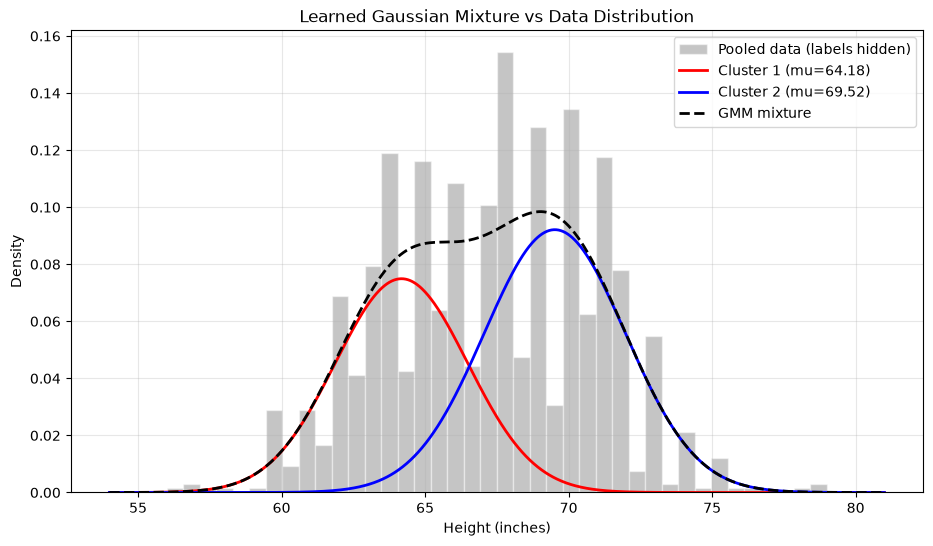

In [33]:
# Plot 1: learned mixture over the data
x_axis = np.linspace(data.min() - 2, data.max() + 2, 1000)
curve1 = PI1 * gaussian_pdf(x_axis, MU1, V1)
curve2 = PI2 * gaussian_pdf(x_axis, MU2, V2)

plt.figure(figsize=(11, 6))
plt.hist(data, bins=40, density=True, alpha=0.45, color='gray',
         edgecolor='white', label='Pooled data (labels hidden)')
plt.plot(x_axis, curve1, 'r-', lw=2, label=f'Cluster 1 (mu={MU1:.2f})')
plt.plot(x_axis, curve2, 'b-', lw=2, label=f'Cluster 2 (mu={MU2:.2f})')
plt.plot(x_axis, curve1 + curve2, 'k--', lw=2, label='GMM mixture')
plt.title('Learned Gaussian Mixture vs Data Distribution')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

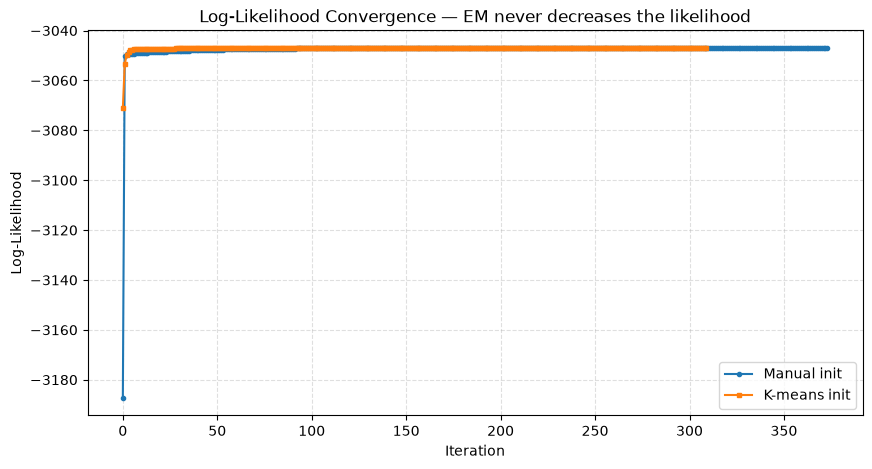

In [34]:
# Plot 2: log-likelihood convergence for both initializations
plt.figure(figsize=(10, 5))
plt.plot([h['it'] for h in history_manual], [h['ll'] for h in history_manual],
         'o-', ms=3, label='Manual init')
plt.plot([h['it'] for h in history_km], [h['ll'] for h in history_km],
         's-', ms=3, label='K-means init')
plt.title('Log-Likelihood Convergence — EM never decreases the likelihood')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.grid(alpha=0.4, linestyle='--')
plt.show()

Conclusions

1. **Implementation.** EM for a 2-component 1-D GMM built entirely from scratch:
   Gaussian PDF, E-step (responsibilities), M-step (weighted parameter updates),
   log-likelihood, convergence check. Initial parameters are function arguments,
   numerical guards protect every division and logarithm, and cluster 1 is pinned
   to the lower mean so labels never swap.
2. **Key finding.** With fathers vs all children pooled together, EM converges to
   two clusters at roughly 64 and 69 inches — which match **female vs male**
   heights, not children vs fathers. The reason: Galton's children are adults, so
   fathers and sons are distributionally identical and cannot be separated by any
   method. EM found the mixture that truly exists. This is the honest
   interpretation we present, verified against the hidden labels.
3. **Global-mean split: no.** The naive hard split produces biased means, shrunken
   (truncated) variances, a false 50/50 weight assumption, and zero uncertainty.
   EM's soft assignments avoid all three, as our side-by-side comparison shows.
4. **Initialization.** EM finds local optima; we ran manual and k-means starts and
   kept the higher-likelihood solution. On poorly separated data, restarts are
   essential.
5. **If distinct parent/child populations are required,** the cross-gender pairings
   (fathers vs daughters, or mothers vs sons) provide genuinely separated Gaussians;
   we keep fathers vs all children here as instructed and interpret the result
   honestly.
